<a href="https://colab.research.google.com/github/vir123-devf/Flower-classification-using-cnn/blob/main/Flower_classification_using_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [132]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout
from tensorflow.keras.models import Sequential



In [83]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos',origin=dataset_url,cache_dir='.',untar = True)
# cache_dir indicates where to download data,'.' means current directory
# untar true will unzip it

In [84]:
data_dir


'./datasets/flower_photos'

In [85]:
import pathlib # pathlib is a library which make handling of files and path easier than directly calling os
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [86]:
list(data_dir.glob('*/*/*.jpg'))[:5]


[PosixPath('datasets/flower_photos/flower_photos/dandelion/7843447416_847e6ba7f4_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/18995294384_77543e96b6_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/4258272073_f616d1e575_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/4082856478_741a411ebb.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/15378782362_4161b23af7_m.jpg')]

In [87]:
image_count = len(list(data_dir.glob('*/*/*.jpg')))
print(image_count)

3670


In [88]:
roses = list(data_dir.glob('*/roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/8524505868_236f4c94b5.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17090993740_fcc8b60b81.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5990626258_697f007308_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16334786972_1b3e71cab8_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15032112248_30c5284e54_n.jpg')]

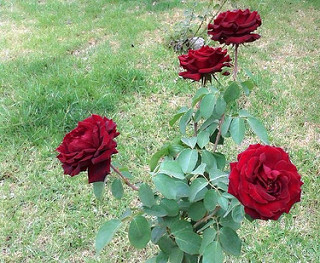

In [89]:
PIL.Image.open(str(roses[4]))

In [90]:
daisy = list(data_dir.glob('*/daisy/*'))
daisy[:5]

[PosixPath('datasets/flower_photos/flower_photos/daisy/7320089276_87b544e341.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/6136947177_47ff445eb4_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/3999978867_c67c79597f_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/2619413565_61a6cd3ac9_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/daisy/9595857626_979c45e5bf_n.jpg')]

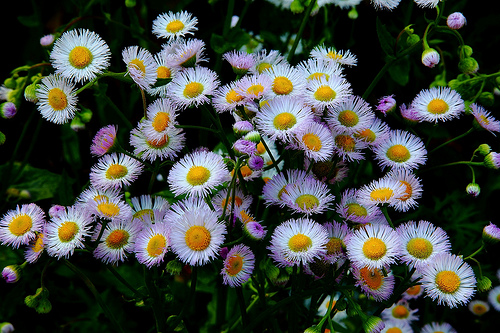

In [91]:
PIL.Image.open(str(daisy[6]))

In [92]:
flowers_images_dict = {
    'daisy':list(data_dir.glob('*/daisy/*')),
    'roses': list(data_dir.glob('*/roses/*')),
    'tulips':list(data_dir.glob('*/tulips/*')),
    'sunflowers':list(data_dir.glob('*/sunflowers/*')),
    'dandelion': list(data_dir.glob('*/dandelion/*')),
}


In [93]:
flowers_labels_dict ={
    'daisy':0,
    'roses': 1,
    'tulips':2,
    'sunflowers':3,
    'dandelion': 4,
}

In [94]:
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/8524505868_236f4c94b5.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17090993740_fcc8b60b81.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5990626258_697f007308_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16334786972_1b3e71cab8_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15032112248_30c5284e54_n.jpg')]

In [95]:
simple_path = str(flowers_images_dict['roses'][0])

In [96]:
img = cv2.imread(simple_path) # image to numpy conversion

In [97]:
print(img)

[[[175 179 173]
  [176 180 174]
  [176 180 174]
  ...
  [154 165 157]
  [150 160 154]
  [150 160 154]]

 [[191 195 189]
  [180 184 178]
  [185 189 183]
  ...
  [153 161 154]
  [151 158 153]
  [151 158 153]]

 [[179 183 178]
  [189 193 187]
  [185 189 183]
  ...
  [173 180 175]
  [159 166 161]
  [156 163 158]]

 ...

 [[201 203 197]
  [200 202 196]
  [200 202 196]
  ...
  [175 189 178]
  [183 197 186]
  [178 192 181]]

 [[197 199 193]
  [208 210 204]
  [198 200 194]
  ...
  [167 178 175]
  [163 174 171]
  [162 173 170]]

 [[200 204 198]
  [199 201 195]
  [202 204 198]
  ...
  [169 190 187]
  [179 194 180]
  [176 190 186]]]


In [98]:
img.shape

(281, 500, 3)

In [99]:
x,y =[],[]
for flower_name,images in flowers_images_dict.items():
    for image in images:
      img = cv2.imread(str(image)) # str is converting posix path to simple string path
      resized_img =cv2.resize(img,(150,150))
      x.append(resized_img)
      y.append(flowers_labels_dict[flower_name])

In [100]:
# converting list to numpy array
x = np.array(x)
y= np.array(y)


In [101]:
# Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=1)


In [102]:

len(x_test)

734

In [103]:
len(x_train)

2936

In [104]:
# scaling
x_train_scaled = x_train/255
x_test_scaled = x_test/255

In [111]:
# Building CNN
num_classes =5
model = Sequential()
model.add(layers.Conv2D(16,3,padding ='same',activation = 'relu')), # 16filters of 3x3 size ,padding provided,activation fxn as relu
model.add(layers.MaxPool2D()),
model.add(layers.Conv2D(32,3,padding ='same',activation = 'relu')),
model.add(layers.MaxPool2D()),
model.add(layers.Conv2D(64,3,padding ='same',activation = 'relu')),
model.add(layers.MaxPool2D()),
model.add(layers.Flatten()),
model.add(layers.Dense(64,activation ='relu')),
model.add(layers.Dense(num_classes,activation ='softmax'))



In [112]:
# compiling the model
model.compile(optimizer ='adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])


In [114]:
# training the model
model.fit(x_train_scaled,y_train,epochs=30)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.3413 - loss: 1.4842
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5771 - loss: 1.0727
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6738 - loss: 0.8632
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7241 - loss: 0.7335
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7952 - loss: 0.5633
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8606 - loss: 0.4092
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9180 - loss: 0.2574
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9588 - loss: 0.1522
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9649 - loss: 0.1235
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9914 - loss: 0.0577
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9925 - loss: 0.0390
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy:

In [115]:
model.evaluate(x_test_scaled,y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6712 - loss: 2.7307


[2.7321205139160156, 0.6621253490447998]

 The test accuracy is very low(varience is high) 66 % and training accuracy is very high (bais is vey low) 100% -- **Overfitting** is occuring .to resolve this ,we use **Data augmentation** and adding some
  **dropout layer **to reduce the overfitting

In [123]:
# improving the accuracy
data_augmentation = keras.Sequential()
# it will flip the image in random direction
data_augmentation.add(layers.RandomFlip('horizontal',input_shape=(150,150,3)))
# it will rotate the image in random direction
data_augmentation.add(layers.RandomRotation(0.5))
# it will zoom the image
data_augmentation.add(layers.RandomZoom(0.6))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


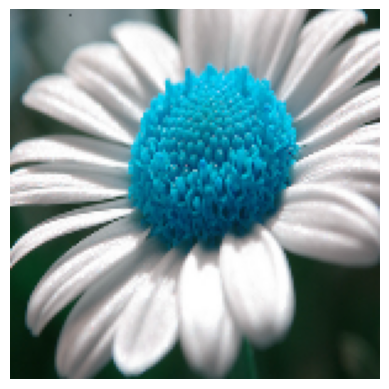

In [125]:
# Original image
plt.axis('off') # off means x and y axis will not be shown
plt.imshow(x[40])

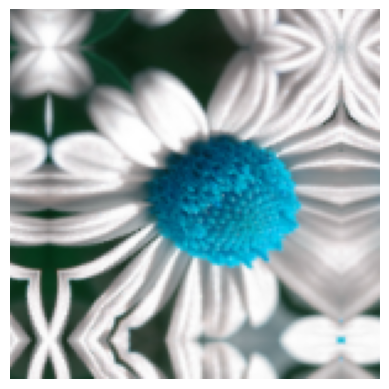

In [127]:
plt.axis('off')
plt.imshow(data_augmentation(x)[40].numpy().astype("uint8"))

In [140]:
# Now building the cnn with data augmentation and drop out layer
num_classes =5
model = Sequential()
model.add(data_augmentation),
model.add(layers.Conv2D(16,3,padding ='same',activation = 'relu')), # 16filters of 3x3 size ,padding provided,activation fxn as relu
model.add(layers.MaxPool2D()),
model.add(layers.Conv2D(32,3,padding ='same',activation = 'relu')),
model.add(layers.MaxPool2D()),
model.add(layers.Conv2D(64,3,padding ='same',activation = 'relu')),
model.add(layers.MaxPool2D()),
model.add(layers.Dropout(0.2)),
model.add(layers.Flatten()),
model.add(layers.Dense(128,activation ='relu')),
model.add(layers.Dense(num_classes,activation ='softmax'))
# compiling the model
model.compile(optimizer ='adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])
# training the model
model.fit(x_train_scaled,y_train,epochs=30)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3523 - loss: 1.4910
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5286 - loss: 1.1676
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5739 - loss: 1.0418
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6051 - loss: 0.9847
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6143 - loss: 0.9750
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6322 - loss: 0.9310
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6458 - loss: 0.8946
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6492 - loss: 0.8952
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6635 - loss: 0.8539
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6723 - loss: 0.8294
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6770 - loss: 0.7921
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy:

In [142]:
model.evaluate(x_test_scaled,y_test)[1]# tells the test accuracy
# we reduced overfitting

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7441 - loss: 0.6589


0.7370572090148926

In [157]:
y_prob = model.predict(x_test_scaled)
y_pred = y_prob.argmax(axis=1)
y_pred[0]

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


np.int64(3)

In [158]:
flowers_dict ={
    0:'daisy',
    1:'roses',
    2:'tulips',
    3:'sunflowers',
    4:'dandelion',
}

Please enter a flower image path of rose,Daisy,Tulip,Dendelion,sunflower from web 
Enter the path of downloaded image: /content/download.jpg


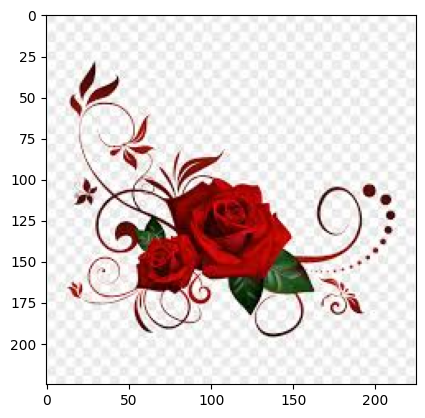

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediction: roses


In [172]:
# predicting for downloaded image(jpg) from website-
from matplotlib import image as mpimg
from PIL import Image
print("Please enter a flower image path of rose,Daisy,Tulip,Dendelion,sunflower from web ")
path = input("Enter the path of downloaded image: ")
img2 = mpimg.imread(path)
imgplt = plt.imshow(img2)
plt.show()

img1 = Image.open(path)
img1 = img1.resize((150,150))
img1 = img1.convert('RGB')
img1 = np.array(img1)
img1 = img1 / 255.0  # optional depending on model preprocessing

# Add batch dimension ---> important step
img1 = np.expand_dims(img1, axis=0)

# Predict
y_p = model.predict(img1)
y_predicted = y_p.argmax(axis=1)
y_predicted

if y_predicted == [0] :
  print("Prediction:",flowers_dict[0])
elif y_predicted == [1] :
  print("Prediction:",flowers_dict[1])
elif y_predicted == [2] :
  print("Prediction:",flowers_dict[2])
elif y_predicted == [3] :
  print("Prediction:",flowers_dict[3])
elif y_predicted == [4]:
  print("Prediction: ",flowers_dict[4])
